# Fay–Herriot: Bayesian hierarchical model

**Navigation**: [← Previous: Classical EBLUP](04_eblup.ipynb) | [Next: Model Comparison →](06_model_comparison.ipynb)

The same area-level model, now with a joint posterior over $(\theta, \beta, \sigma_u^2)$. A conjugate Gibbs sampler is the workhorse; a PyMC NUTS fit is the independent check.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'sae_utils.py').exists():
    PROJ_DIR = Path('projects/small-area-estimation').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from sae_utils import (
    load_panel, modelling_frame, design_matrix, eblup_fh, fh_reml_sigma_u,
    jackknife_mse, gibbs_fh, summarise_theta, posterior_predictive_y,
    rhat_split, coverage_rate, project_data_dir,
)

def display_plotly(fig):
    """Embed Plotly with CDN JS — fig.show() is blank in Jupyter Book HTML."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

FIG_DIR = PROJ_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR = project_data_dir()
PANEL = load_panel()
MODEL = modelling_frame(PANEL)
print(f'Panel: {len(PANEL)} local authorities; modelling subset: {len(MODEL)}')
print(f'Period (APS / ONS model-based): {PANEL["direct_period"].dropna().iloc[0]}')


Panel: 348 local authorities; modelling subset: 136
Period (APS / ONS model-based): Apr 2025-Mar 2026


## Why Bayes here

The EBLUP is a **posterior mean** for $\theta_i$ under a flat prior on $\beta$ and a plug-in $\hat\sigma_u^2$. That plug-in step is the awkward bit: $g_3$ is a Taylor correction for not knowing $\sigma_u^2$. A hierarchical Bayesian model just samples it.

$$
\begin{aligned}
y_i \mid \theta_i &\sim N(\theta_i, \psi_i), \\
\theta_i \mid \beta, \sigma_u^2 &\sim N(x_i'\beta, \sigma_u^2), \\
\beta &\sim N(0, \tau^2 I), \\
\sigma_u^2 &\sim \mathrm{InverseGamma}(a, b).
\end{aligned}
$$

This is conjugate, so Gibbs is exact (up to Monte Carlo) and cheap. NUTS in PyMC does not need conjugacy; we use it to confirm that the posterior is not an artefact of the Inverse-Gamma prior. A half-normal on $\sigma_u$ (PyMC) and IG$(0.5,0.5)$ on $\sigma_u^2$ (Gibbs) are **not** the same prior — if $\theta_i$ posteriors still agree, the likelihood is doing the work.

That last point is the frequentist/Bayes distinction that actually matters here. It is **not** that one produces point estimates and the other intervals. Both produce both. The difference is whether uncertainty in $\sigma_u^2$ is a correction term or a sampled parameter, and whether you are willing to insert a prior that remains informative when $m$ is small.

## Gibbs sampler

Full conditionals (Gelman et al. notation; scale parameterisation of IG):

- $\theta_i \mid \cdot \sim N\big(v_i(y_i/\psi_i + x_i'\beta/\sigma_u^2),\, v_i\big)$, $v_i^{-1} = \psi_i^{-1} + \sigma_u^{-2}$
- $\beta \mid \cdot \sim N(m_\beta, V_\beta)$ with precision $X'X/\sigma_u^2 + \tau^{-2}I$
- $\sigma_u^2 \mid \cdot \sim \mathrm{IG}(a+m/2,\, b + \tfrac12\|\theta-X\beta\|^2)$

$\tau^2 = 10^4$ is weakly informative on the percentage-point scale.

In [2]:
gibbs = gibbs_fh(MODEL, covariates=['claimant_rate'], draws=4000, burn=1000, thin=2, seed=42)
theta_g = gibbs['theta']
sum_g = summarise_theta(theta_g, index=MODEL.index)
bayes = MODEL.join(sum_g)
print(f"Kept draws: {gibbs['draws']}")
print(f"Posterior mean σ²_u = {gibbs['sigma_u2'].mean():.3f}  "
      f"median={np.median(gibbs['sigma_u2']):.3f}")
print('β posterior means:', dict(zip(gibbs['coef_names'], np.round(gibbs['beta'].mean(0), 3))))
for i, name in enumerate(gibbs['coef_names']):
    d = gibbs['beta'][:, i]
    print(f"  {name}: mean={d.mean():.3f}  95% CI=({np.quantile(d,0.025):.3f}, {np.quantile(d,0.975):.3f})")
print(f"split-R̂(σ²_u) ≈ {rhat_split(gibbs['sigma_u2']):.3f}")
bayes[['GEOGRAPHY_NAME','direct_rate','bayes_mean','bayes_ci_lo','bayes_ci_hi']].head()


Kept draws: 1500
Posterior mean σ²_u = 0.949  median=0.908
β posterior means: {'intercept': np.float64(2.38), 'claimant_rate': np.float64(0.651)}
  intercept: mean=2.380  95% CI=(1.598, 3.181)
  claimant_rate: mean=0.651  95% CI=(0.472, 0.835)
split-R̂(σ²_u) ≈ 1.004


,GEOGRAPHY_NAME,direct_rate,bayes_mean,bayes_ci_lo,bayes_ci_hi
0,Barking and Dagenham,6.1,6.951729,5.193146,8.662916
1,Barnet,5.5,5.587427,4.068580,7.265468
2,Barnsley,2.6,3.356316,2.140859,4.516208
3,Bath and North East Somerset,4.6,4.038717,2.719589,5.446427
4,Bexley,7.3,5.172318,3.536707,6.882331


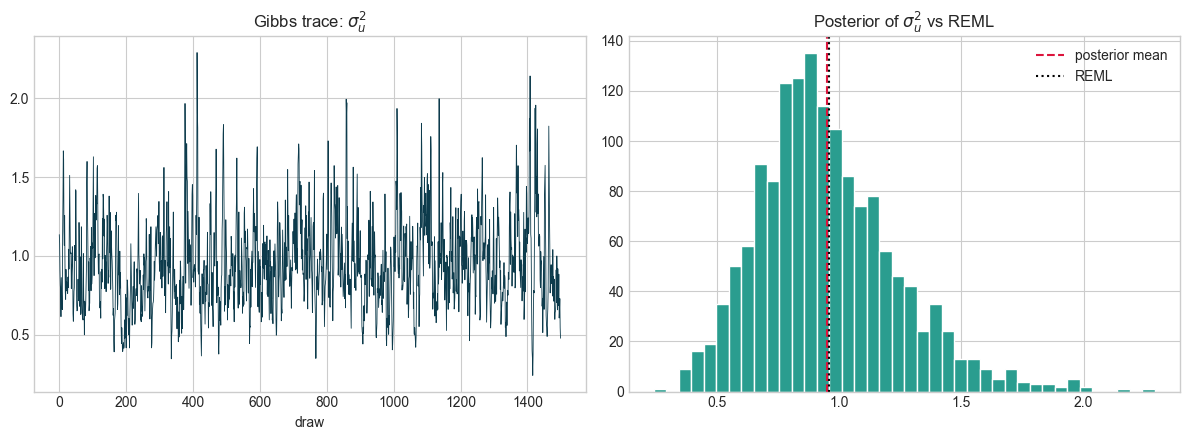

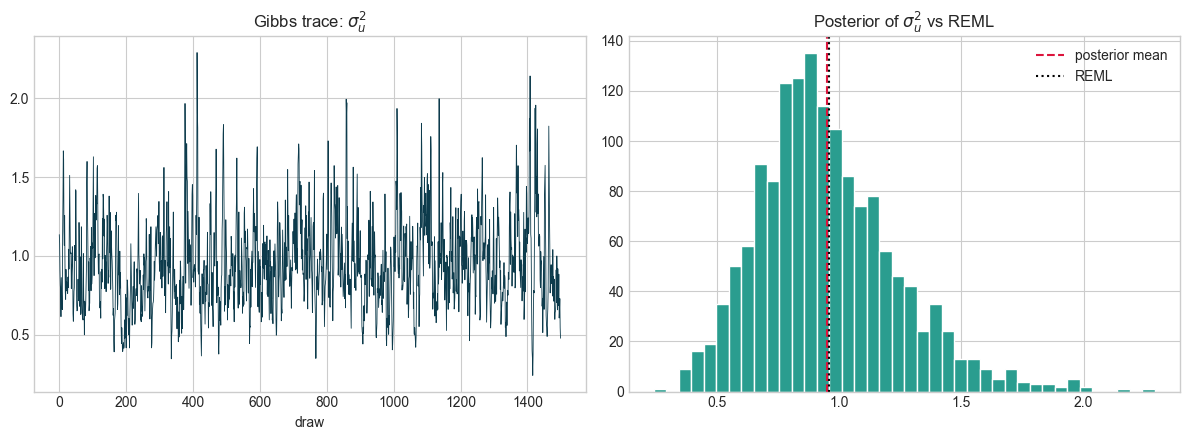

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(gibbs['sigma_u2'], lw=0.6, color='#0d3b4c')
axes[0].set_title(r'Gibbs trace: $\sigma_u^2$')
axes[0].set_xlabel('draw')
axes[1].hist(gibbs['sigma_u2'], bins=40, color='#2a9d8f', edgecolor='white')
axes[1].axvline(gibbs['sigma_u2'].mean(), color='crimson', ls='--', label='posterior mean')
e = eblup_fh(MODEL, covariates=['claimant_rate'])
axes[1].axvline(e.attrs['fit']['sigma_u2'], color='black', ls=':', label='REML')
axes[1].set_title(r'Posterior of $\sigma_u^2$ vs REML')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '05_sigma_u_posterior.png', dpi=120)
fig


## PyMC / NUTS

The non-conjugate specification puts a half-normal prior on $\sigma_u$ and independent $N(0,10^2)$ priors on $\beta$. If PyMC is unavailable in this runtime, the cell records the failure and the Gibbs posterior remains the Bayesian result.

In [4]:
pymc_ok = False
pymc_sum = None
try:
    from sae_utils import fit_pymc_fh
    pymc_fit = fit_pymc_fh(
        MODEL, covariates=['claimant_rate'],
        draws=600, tune=600, chains=2, seed=42,
    )
    pymc_sum = summarise_theta(pymc_fit['theta'], index=MODEL.index).add_prefix('pymc_')
    pymc_ok = True
    print(f"NUTS draws: {pymc_fit['draws']}")
    print(f"Posterior mean σ²_u (NUTS) = {pymc_fit['sigma_u2'].mean():.3f}")
    print(f"split-R̂(σ_u) ≈ {rhat_split(np.sqrt(pymc_fit['sigma_u2'])):.3f}")
except Exception as exc:
    print('PyMC fit skipped:', type(exc).__name__, '-', exc)


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [sigma_u, beta, theta]


Output()

Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 1 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


NUTS draws: 1200
Posterior mean σ²_u (NUTS) = 0.973
split-R̂(σ_u) ≈ 1.002


corr(Gibbs, NUTS) θ means: 0.9998
count    136.000
mean      -0.001
std        0.026
min       -0.079
25%       -0.019
50%        0.001
75%        0.017
max        0.059
dtype: float64


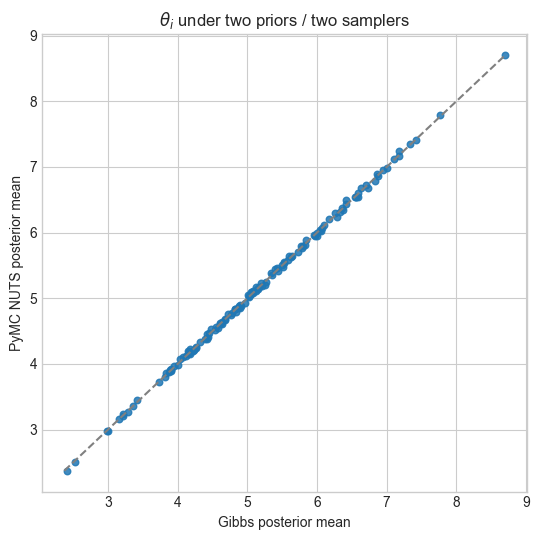

In [5]:
if pymc_ok:
    cmp = pd.DataFrame({
        'gibbs_mean': bayes['bayes_mean'],
        'pymc_mean': pymc_sum['pymc_bayes_mean'],
    })
    print('corr(Gibbs, NUTS) θ means:', np.corrcoef(cmp['gibbs_mean'], cmp['pymc_mean'])[0,1].round(4))
    print((cmp['gibbs_mean'] - cmp['pymc_mean']).describe().round(3))
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(cmp['gibbs_mean'], cmp['pymc_mean'], s=22, alpha=0.85)
    lims = [cmp.min().min(), cmp.max().max()]
    ax.plot(lims, lims, '--', color='grey')
    ax.set_xlabel('Gibbs posterior mean')
    ax.set_ylabel('PyMC NUTS posterior mean')
    ax.set_title(r'$\theta_i$ under two priors / two samplers')
    fig.tight_layout()
    fig.savefig(FIG_DIR / '05_gibbs_vs_pymc.png', dpi=120)
    fig
else:
    print('No NUTS comparison in this runtime.')


## Posterior predictive check

Draw $y_i^{\mathrm{rep}} \sim N(\theta_i^{(s)}, \psi_i)$ and compare the replicated distribution of, say, the cross-area variance of $y$ to the observed one. A linking model that is too rigid (tiny $\sigma_u^2$) under-replicates the spread of the direct estimates; one that ignores $\psi_i$ over-replicates it.

Observed Var(y) = 3.562
Replicated mean Var(y) = 3.587  (PPP = 0.515)


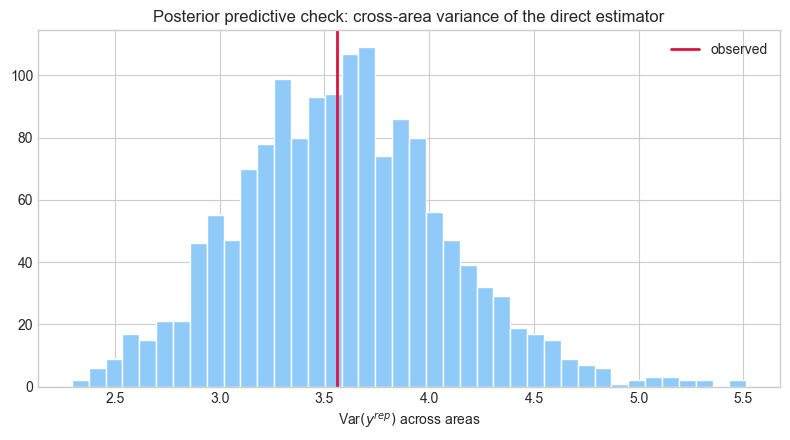

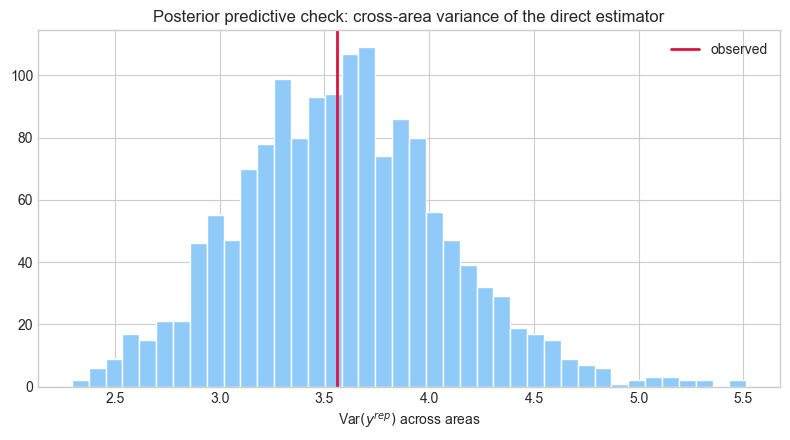

In [6]:
y = MODEL['direct_rate'].to_numpy()
psi = MODEL['psi'].to_numpy()
y_rep = posterior_predictive_y(theta_g, psi, seed=1)
obs_var = y.var(ddof=1)
rep_var = y_rep.var(axis=1, ddof=1)
pval = (rep_var >= obs_var).mean()
print(f'Observed Var(y) = {obs_var:.3f}')
print(f'Replicated mean Var(y) = {rep_var.mean():.3f}  (PPP = {pval:.3f})')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(rep_var, bins=40, color='#90caf9', edgecolor='white')
ax.axvline(obs_var, color='crimson', lw=2, label='observed')
ax.set_xlabel(r'Var$(y^{rep})$ across areas')
ax.set_title('Posterior predictive check: cross-area variance of the direct estimator')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '05_ppc_variance.png', dpi=120)
fig


## Key takeaways

- The Bayesian $\theta_i$ posterior mean **is** an EBLUP with $\sigma_u^2$ integrated rather than plugged in; it should sit close to the REML EBLUP when $m$ is large.
- Credible intervals automatically include uncertainty in $\beta$ and $\sigma_u^2$. They still assume $\psi_i$ known and $u_i$ iid normal.
- Prior disagreement (IG vs half-normal) is a feature: if Gibbs and NUTS diverge, the variance component is weakly identified and the EBLUP MSE formula is in the same fragile regime.

---

**Navigation**: [← Previous: Classical EBLUP](04_eblup.ipynb) | [Next: Model Comparison →](06_model_comparison.ipynb)
